In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
from config import (SPE1_PICKLE_ROOT, DICT_CELL_TYPE, DICT_PATCH_TYPE,
                    DICT_CORT_DEPTH, DICT_DARK_NEURONS, DICT_EAP_WAV)

import os

# ── Publication style ──────────────────────────────────────────────────────────
sns.set_theme(style='ticks', font_scale=1.0, rc={
    'axes.linewidth':      2.0,
    'xtick.major.width':   2.0,
    'ytick.major.width':   2.0,
    'xtick.major.size':    4.5,
    'ytick.major.size':    4.5,
    'font.size':           14,
    'axes.titlesize':      14,
    'axes.labelsize':      13,
    'xtick.labelsize':     13,
    'ytick.labelsize':     12,
    'legend.fontsize':     11,
    'figure.dpi':         150,
})

PW = 2.35   # panel width  (inches) — 3 per row on A4 portrait
PH = 3.2    # panel height (inches)

COL_PC  = '#9467BD'   # muted purple — pyramidal cells
COL_IN  = '#56B4E9'   # sky blue     — interneurons

COL_EAP  = '#009E73'
COL_DARK = '#CC79A7'
COL_NO   = '#888888'

In [2]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


In [3]:
# ── Build metadata DataFrame ───────────────────────────────────────────────────
rows = []
for pkl in sorted(glob.glob(SPE1_PICKLE_ROOT + '/cluster_pickles/c*_cluster_df.pkl')):
    cnum = int(pkl.split('/')[-1].replace('_cluster_df.pkl','').lstrip('c'))
    df   = pickle.load(open(pkl, 'rb'))
    t    = df['spk_times_ms'].values
    rows.append(dict(
        cell_num     = cnum,
        cell_id      = f'c{cnum}',
        cell_type    = DICT_CELL_TYPE.get(cnum, 'unknown'),
        patch_type   = DICT_PATCH_TYPE.get(cnum, 'unknown'),
        cort_depth   = DICT_CORT_DEPTH.get(cnum, np.nan),
        dark_neuron  = DICT_DARK_NEURONS.get(cnum, False),
        eap_visible  = DICT_EAP_WAV.get(cnum, False),
        n_spikes     = len(df),
        duration_min = (t.max() - t.min()) / 1000 / 60,
        firing_rate  = len(df) / ((t.max() - t.min()) / 1000),
    ))

meta = pd.DataFrame(rows)
meta['method'] = meta['patch_type'].apply(
    lambda x: 'Whole-cell' if 'WC' in str(x) else 'Juxtacellular'
)

# Three-way EAP status per paper definition:
# - Clear EAP: PSTA shows detectable canonical waveform
# - Dark neuron candidate: close to probe, good session, >200 spikes — no EAP despite ideal conditions
# - No EAP / recording issue: lack of EAP likely explained by probe drift or misalignment
def _eap_status(row):
    if row['eap_visible']:
        return 'Clear EAP'
    elif row['dark_neuron']:
        return 'Dark neuron\ncandidate'
    else:
        return 'No EAP\n(recording issue)'
meta['eap_status'] = meta.apply(_eap_status, axis=1)

print(f'n = {len(meta)} cells')
print(meta['eap_status'].value_counts().to_string())

n = 40 cells
Clear EAP                    20
No EAP\n(recording issue)    15
Dark neuron\ncandidate        5


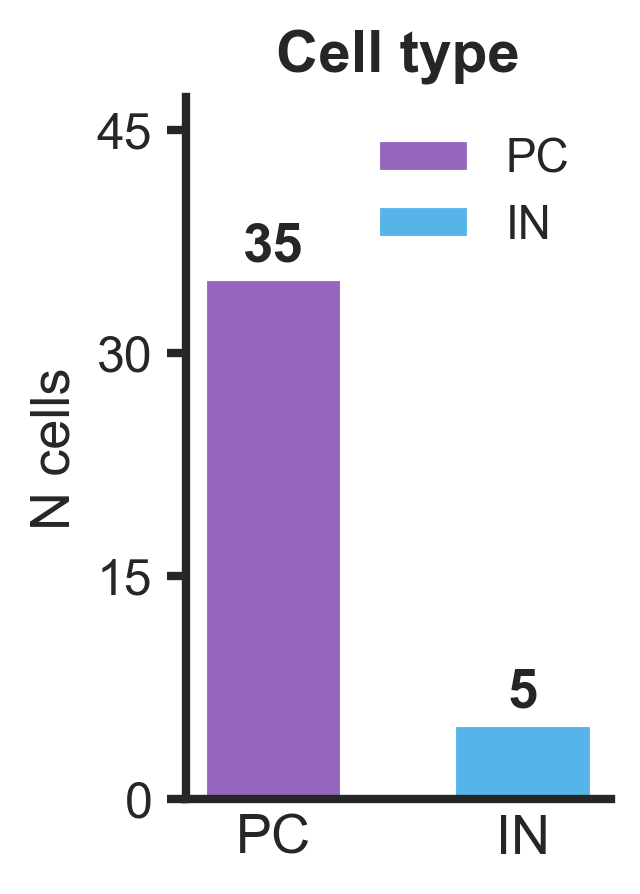

In [4]:
# ── Cell type breakdown ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
ct_counts = meta['cell_type'].value_counts().reindex(['PC', 'IN'])
bars = ax.bar(ct_counts.index, ct_counts.values,
              color=[COL_PC, COL_IN], edgecolor='white', width=0.55)
for bar, val in zip(bars, ct_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
# legend here only — used as shared key for all panels
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=COL_PC, label='PC'),
                   Patch(facecolor=COL_IN, label='IN')],
          frameon=False, loc='upper right')
ax.set_ylabel('N cells')
ax.set_title('Cell type', fontweight='bold')
ax.set_ylim(0, ct_counts.max() * 1.35)
ax.yaxis.set_major_locator(plt.MaxNLocator(4, integer=True))
ax.tick_params(axis='x', length=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

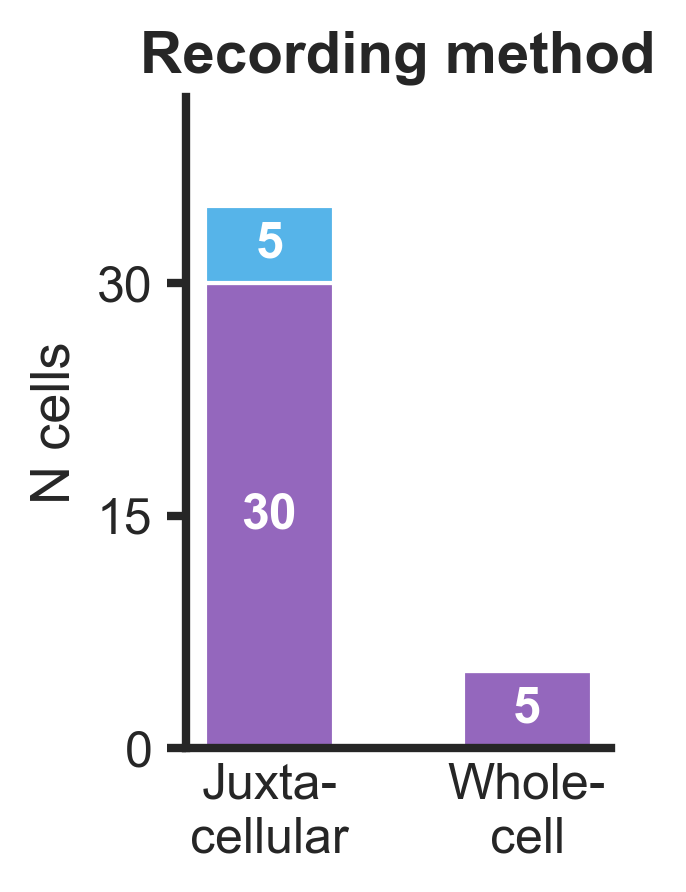

In [5]:
# ── Recording method ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
method_ct = meta.groupby(['method', 'cell_type']).size().unstack(fill_value=0)
method_ct = method_ct.reindex(['Juxtacellular', 'Whole-cell'])
bot = np.zeros(len(method_ct))
for ct, col in [('PC', COL_PC), ('IN', COL_IN)]:
    if ct in method_ct.columns:
        vals = method_ct[ct].values
        ax.bar(method_ct.index, vals, bottom=bot, color=col,
               edgecolor='white', width=0.5)
        for i, (v, b) in enumerate(zip(vals, bot)):
            if v > 0:
                ax.text(i, b + v / 2, str(v), ha='center', va='center',
                        fontsize=12, color='white', fontweight='bold')
        bot += vals
ax.set_xticks([0, 1])
ax.set_xticklabels(['Juxta-\ncellular', 'Whole-\ncell'], fontsize=12)
ax.set_ylabel('N cells')
ax.set_title('Recording method', fontweight='bold')
ax.set_ylim(0, bot.max() * 1.2)
ax.yaxis.set_major_locator(plt.MaxNLocator(4, integer=True))
ax.tick_params(axis='x', length=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

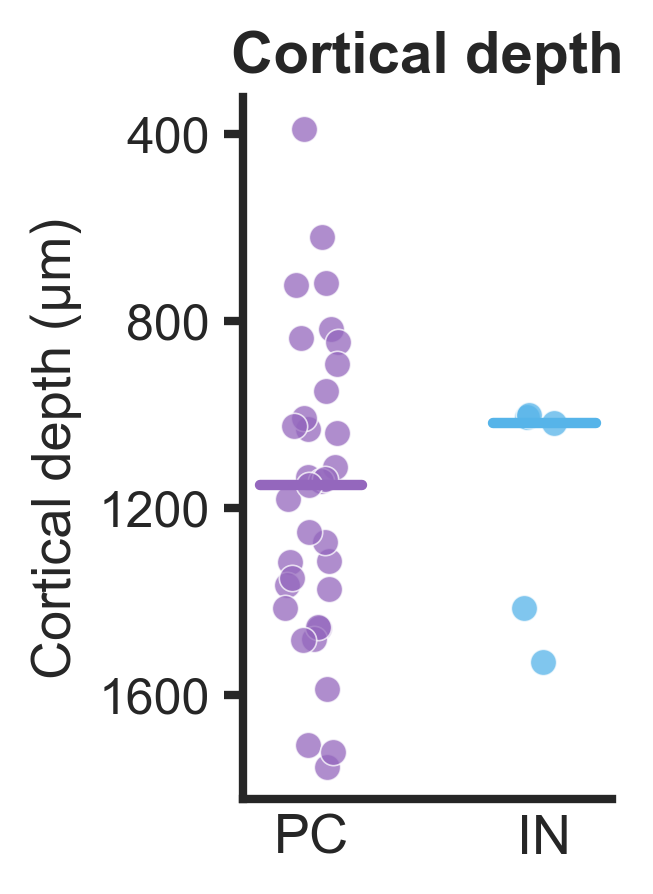

In [6]:
# ── Cortical depth ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
rng = np.random.default_rng(42)
for xi, (ct, col) in enumerate([('PC', COL_PC), ('IN', COL_IN)]):
    sub = meta[meta.cell_type == ct].dropna(subset=['cort_depth'])
    jitter = rng.uniform(-0.12, 0.12, len(sub))
    ax.scatter(xi + jitter, sub['cort_depth'],
               color=col, s=40, alpha=0.75, edgecolors='white', lw=0.4, zorder=4)
    med = sub['cort_depth'].median()
    ax.plot([xi - 0.22, xi + 0.22], [med, med], color=col, lw=2.5, zorder=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['PC', 'IN'])
ax.set_ylabel('Cortical depth (µm)')
ax.set_title('Cortical depth', fontweight='bold')
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.invert_yaxis()
ax.tick_params(axis='x', length=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

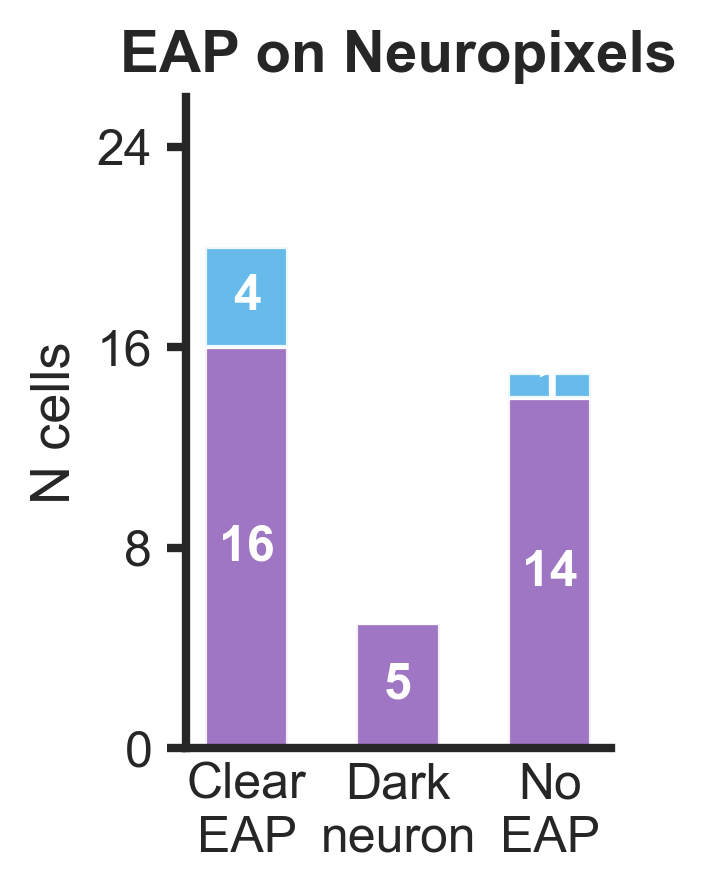

In [7]:
# ── EAP detectability on Neuropixels ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
STATUS_ORDER = ['Clear EAP', 'Dark neuron\ncandidate', 'No EAP\n(recording issue)']
eap_ct = (meta.groupby(['eap_status', 'cell_type']).size()
            .unstack(fill_value=0)
            .reindex([s for s in STATUS_ORDER if s in meta['eap_status'].unique()])
            .fillna(0))
x   = np.arange(len(eap_ct))
bot = np.zeros(len(eap_ct))
for ct, col in [('PC', COL_PC), ('IN', COL_IN)]:
    if ct in eap_ct.columns:
        vals = eap_ct[ct].values.astype(float)
        ax.bar(x, vals, bottom=bot, width=0.55, color=col, edgecolor='white', alpha=0.9)
        for xi, (v, b) in enumerate(zip(vals, bot)):
            if v > 0:
                ax.text(xi, b + v / 2, str(int(v)), ha='center', va='center',
                        fontsize=12, color='white', fontweight='bold')
        bot += vals
ax.set_xticks(x)
ax.set_xticklabels(['Clear\nEAP', 'Dark\nneuron', 'No\nEAP'], fontsize=12)
ax.set_ylabel('N cells')
ax.set_title('EAP on Neuropixels', fontweight='bold')
ax.set_ylim(0, bot.max() * 1.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(4, integer=True))
ax.tick_params(axis='x', length=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

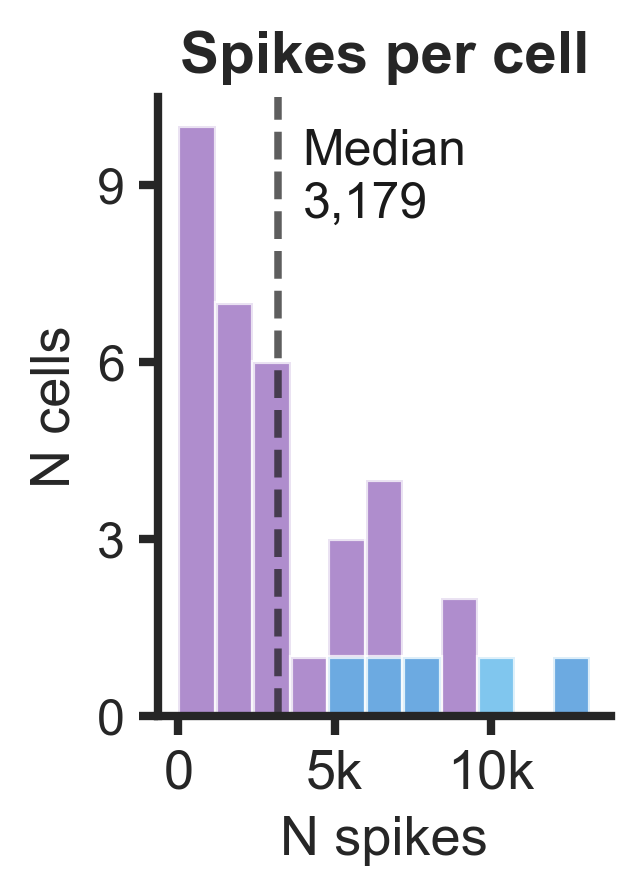

In [8]:
# ── Spikes per cell ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
bins = np.linspace(0, meta['n_spikes'].max() * 1.05, 12)
for ct, col in [('PC', COL_PC), ('IN', COL_IN)]:
    ax.hist(meta[meta.cell_type == ct]['n_spikes'], bins=bins,
            color=col, alpha=0.75, edgecolor='white')
med = meta['n_spikes'].median()
ax.axvline(med, color='k', lw=1.8, ls='--', alpha=0.7)
ax.text(med * 1.25, ax.get_ylim()[1] * 0.95, f'Median\n{int(med):,}',
        fontsize=12, va='top', ha='left', color='k')
ax.set_xlabel('N spikes')
ax.set_ylabel('N cells')
ax.set_title('Spikes per cell', fontweight='bold')
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(4, integer=True))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

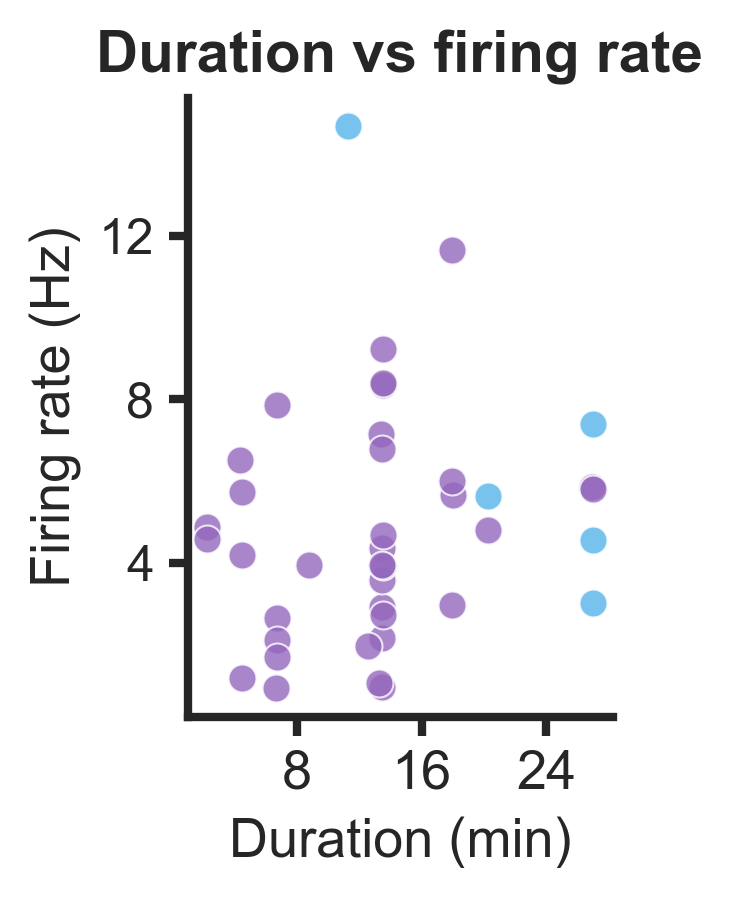

In [9]:
# ── Recording duration vs firing rate ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PW, PH))
for ct, col in [('PC', COL_PC), ('IN', COL_IN)]:
    sub = meta[meta.cell_type == ct]
    ax.scatter(sub['duration_min'], sub['firing_rate'],
               color=col, s=45, alpha=0.8, edgecolors='white', lw=0.5, zorder=4)
ax.set_xlabel('Duration (min)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Duration vs firing rate', fontweight='bold')
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Panel D — EAP category definitions (Marques-Smith et al. 2020)

EAP detectability was assessed by computing the **patch spike-triggered average (PSTA)** of the Neuropixels signal around every patch-clamp spike. All neurons were within 10–144 µm of the nearest probe channel.

- **Clear EAP** — PSTA reveals a canonical extracellular waveform with peak-peak amplitude > 10 µV. The neuron is detectable by standard spike sorting.

- **Dark neuron candidate** — No clear PSTA waveform despite: (1) being within ~50 µm of the probe, (2) ≥200 spikes recorded, and (3) recorded in a session where other neurons *were* detectable extracellularly. Absence of EAP is unlikely to be a recording artefact — these cells may be genuinely undetectable by extracellular electrodes.

- **No EAP / recording issue** — No clear PSTA waveform, but the absence is likely explained by technical factors: probe drift, manipulator misalignment, or bending of the probe after brain entry (sessions where *no* cells were detectable, or sessions that started with detectable cells and ended without). Not candidates for "dark neuron" classification.